✅ Tahap 1: Dataset asli berhasil dimuat
✅ Proses Advanced Data Cleaning Selesai.

     LAPORAN DETIL KUALITAS DATA (HASIL HITUNGAN)
1. STATUS DATA OUTLIERS (PENCILAN EKSTREM):
   Berdasarkan rumus Interquartile Range (IQR), terdeteksi:
   - Kolom 'Age'         : 52 data pencilan.
   - Kolom 'BMI'         : 25 data pencilan.
   - Kolom 'Avg_Glucose' : 69 data pencilan.
   -> Total Keseluruhan  : 146 data outlier berhasil di-capping.

2. STATUS MISSING VALUE (DATA KOSONG):
   - Kolom 'BMI'         : 0 data kosong ditemukan.
   - Kolom 'Avg_Glucose' : 0 data kosong ditemukan.
   -> Keterangan: Jika bernilai 0, artinya file kamu sudah bersih dari data kosong.

3. STATUS DATA DUPLIKAT & INKONSISTENSI:
   - Baris Duplikat      : 0 baris kembar terdeteksi dari total 10000 data.
   - Spasi Gaib (Teks)   : Semua karakter spasi liar di ujung teks sudah dipangkas otomatis.

💾 File 1: 'stroke_data_hanya_cleaning.csv' BERHASIL DISIMPAN!


              BUSINESS QUESTIONS
1. Faktor apa saja yang mem

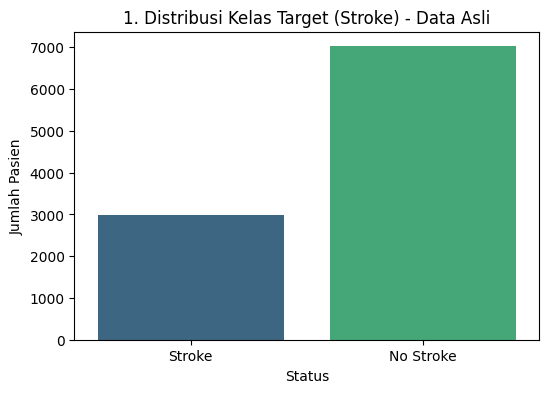

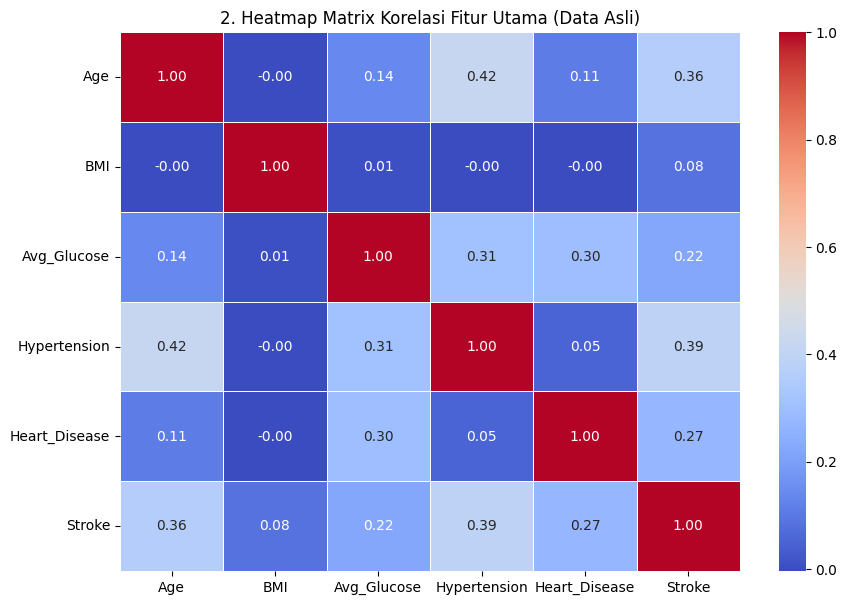

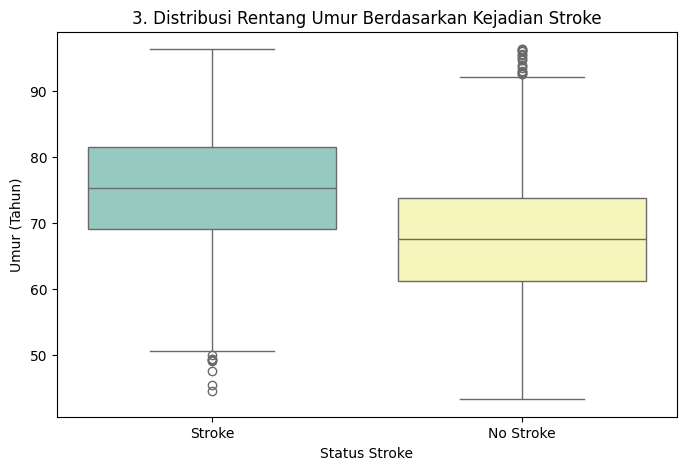

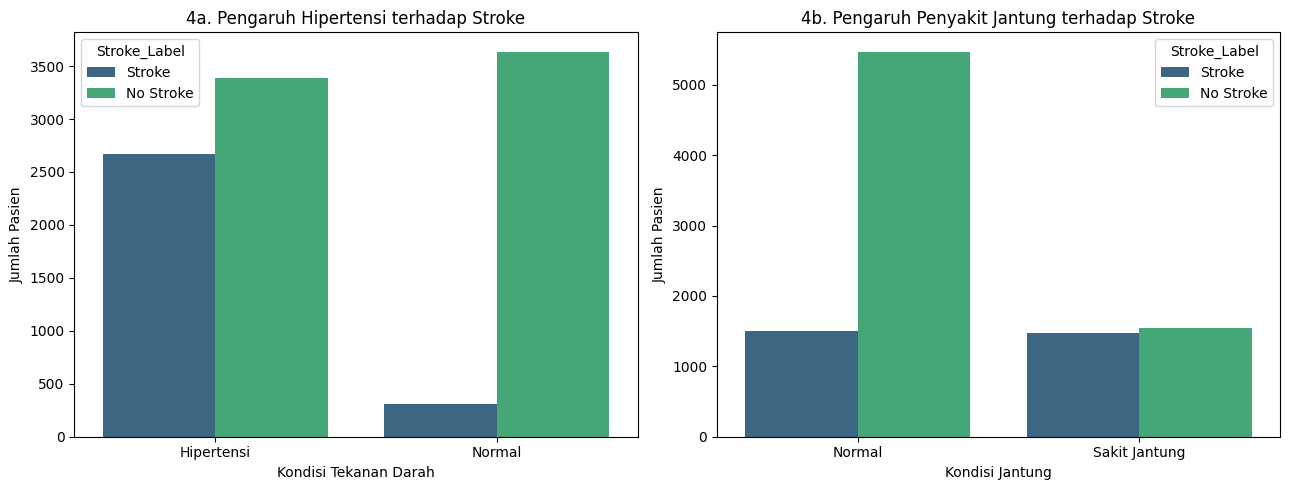


            EXPLANATORY ANALYSIS
1. Faktor yang memengaruhi risiko stroke berdasarkan visualisasi korelasi meliputi:
   Usia (Age), Hipertensi (Hypertension), Penyakit Jantung (Heart_Disease), BMI, dan Kadar Glukosa.

2. Visualisasi boxplot umur memperlihatkan rentang median pasien stroke jauh lebih tinggi,
   artinya risiko kejadian stroke meningkat signifikan seiring bertambahnya usia pasien.

3. Grafik komorbiditas membuktikan pasien dengan riwayat medis Hipertensi atau Penyakit Jantung
   memiliki rasio kejadian stroke yang jauh lebih tinggi dibanding orang dengan kondisi normal.

4. BMI dan Kadar Glukosa yang telah dibersihkan dari outlier ekstrem menunjukkan akumulasi kasus
   stroke padat pada area kategori berat badan berlebih (Overweight) dan gula darah tinggi.

5. Dataset awal dikonfirmasi mengalami ketidakseimbangan kelas (imbalance) yang ekstrem.
   Langkah penanganan SMOTE di bawah berhasil menyeimbangkan proporsi data menjadi 50:50 demi akurasi ML.


⚙️ Menjalankan Pipel

In [1]:
# ==============================================================================
# UNTUK PEMBUATAN DASHBOARD
# ==============================================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# 1. GATHERING DATA
df = pd.read_csv('/content/stroke_data.csv')
print("✅ Tahap 1: Dataset asli berhasil dimuat")

# 2. ASSESSING DATA (Menyimpan nilai awal sebelum dibersihkan)
jumlah_baris_asli = df.shape[0]
missing_bmi_asli = df['BMI'].isnull().sum()
missing_glucose_asli = df['Avg_Glucose'].isnull().sum()
jumlah_duplikat = df.duplicated().sum()

# 3. ADVANCED DATA CLEANING
# --- A. Handling Data Duplikat ---
if jumlah_duplikat > 0:
    df.drop_duplicates(inplace=True)

# --- B. Handling Missing Value ---
cols_to_check = ['BMI', 'Avg_Glucose']
for col in cols_to_check:
    df[col] = df[col].fillna(df[col].median())

# --- C. Handling Text Inconsistency (Spasi Gaib) ---
kolom_kategori = ['Gender', 'SES', 'Smoking_Status']
for col in kolom_kategori:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip()

# --- D. Handling Outliers menggunakan Metode IQR Capping & Menghitung Jumlahnya ---
total_outliers = 0
num_cols = ['Age', 'BMI', 'Avg_Glucose']
dict_outliers = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Hitung jumlah pencilan asli yang beneran ada di data kamu saat ini
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    dict_outliers[col] = outlier_count
    total_outliers += outlier_count

    # Eksekusi pangkas outlier (Capping)
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("✅ Proses Advanced Data Cleaning Selesai.")

print(f"""
======================================================
     LAPORAN DETIL KUALITAS DATA (HASIL HITUNGAN)
======================================================
1. STATUS DATA OUTLIERS (PENCILAN EKSTREM):
   Berdasarkan rumus Interquartile Range (IQR), terdeteksi:
   - Kolom 'Age'         : {dict_outliers['Age']} data pencilan.
   - Kolom 'BMI'         : {dict_outliers['BMI']} data pencilan.
   - Kolom 'Avg_Glucose' : {dict_outliers['Avg_Glucose']} data pencilan.
   -> Total Keseluruhan  : {total_outliers} data outlier berhasil di-capping.

2. STATUS MISSING VALUE (DATA KOSONG):
   - Kolom 'BMI'         : {missing_bmi_asli} data kosong ditemukan.
   - Kolom 'Avg_Glucose' : {missing_glucose_asli} data kosong ditemukan.
   -> Keterangan: Jika bernilai 0, artinya file kamu sudah bersih dari data kosong.

3. STATUS DATA DUPLIKAT & INKONSISTENSI:
   - Baris Duplikat      : {jumlah_duplikat} baris kembar terdeteksi dari total {jumlah_baris_asli} data.
   - Spasi Gaib (Teks)   : Semua karakter spasi liar di ujung teks sudah dipangkas otomatis.
======================================================
""")

# 4. OUTPUT FILE 1 (UNTUK DASHBOARD STREAMLIT)
df.to_csv('stroke_data_hanya_cleaning.csv', index=False)
print("💾 File 1: 'stroke_data_hanya_cleaning.csv' BERHASIL DISIMPAN!\n")


# =========================================================
# 5. MENDEFINISIKAN PERTANYAAN BISNIS
# =========================================================
print("""
=================================================
              BUSINESS QUESTIONS
=================================================
1. Faktor apa saja yang memengaruhi risiko stroke?
2. Apakah usia memiliki hubungan terhadap kejadian stroke?
3. Apakah hipertensi dan penyakit jantung meningkatkan risiko stroke?
4. Bagaimana pengaruh BMI dan kadar glukosa terhadap stroke?
5. Apakah dataset mengalami imbalance sebelum dilakukan SMOTE?
""")

# =========================================================
# 6. EXPLORATORY DATA ANALYSIS (EDA) & VISUALISASI DATA
# =========================================================
print("\n📊 Memulai proses pembuatan grafik visualisasi...")

df_vis = df.copy()
df_vis['Stroke_Label'] = df_vis['Stroke'].map({1: 'Stroke', 0: 'No Stroke'})
df_vis['Hypertension_Label'] = df_vis['Hypertension'].map({1: 'Hipertensi', 0: 'Normal'})
df_vis['Heart_Disease_Label'] = df_vis['Heart_Disease'].map({1: 'Sakit Jantung', 0: 'Normal'})

# Grafik 1: Distribusi Imbalance Target
plt.figure(figsize=(6, 4))
sns.countplot(x='Stroke_Label', data=df_vis, palette='viridis')
plt.title('1. Distribusi Kelas Target (Stroke) - Data Asli')
plt.xlabel('Status')
plt.ylabel('Jumlah Pasien')
plt.show()

# Grafik 2: Heatmap Korelasi
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[['Age', 'BMI', 'Avg_Glucose', 'Hypertension', 'Heart_Disease', 'Stroke']].corr(),
    annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5
)
plt.title('2. Heatmap Matrix Korelasi Fitur Utama (Data Asli)')
plt.show()

# Grafik 3: Distribusi Umur Berdasarkan Stroke
plt.figure(figsize=(8, 5))
sns.boxplot(x='Stroke_Label', y='Age', data=df_vis, palette='Set3')
plt.title('3. Distribusi Rentang Umur Berdasarkan Kejadian Stroke')
plt.xlabel('Status Stroke')
plt.ylabel('Umur (Tahun)')
plt.show()

# Grafik 4: Komorbiditas Hipertensi & Sakit Jantung
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(x='Hypertension_Label', hue='Stroke_Label', data=df_vis, ax=axes[0], palette='viridis')
axes[0].set_title('4a. Pengaruh Hipertensi terhadap Stroke')
axes[0].set_xlabel('Kondisi Tekanan Darah')
axes[0].set_ylabel('Jumlah Pasien')

sns.countplot(x='Heart_Disease_Label', hue='Stroke_Label', data=df_vis, ax=axes[1], palette='viridis')
axes[1].set_title('4b. Pengaruh Penyakit Jantung terhadap Stroke')
axes[1].set_xlabel('Kondisi Jantung')
axes[1].set_ylabel('Jumlah Pasien')
plt.tight_layout()
plt.show()

# =========================================================
# 7. EXPLANATORY ANALYSIS
# =========================================================
print("""
=================================================
            EXPLANATORY ANALYSIS
=================================================
1. Faktor yang memengaruhi risiko stroke berdasarkan visualisasi korelasi meliputi:
   Usia (Age), Hipertensi (Hypertension), Penyakit Jantung (Heart_Disease), BMI, dan Kadar Glukosa.

2. Visualisasi boxplot umur memperlihatkan rentang median pasien stroke jauh lebih tinggi,
   artinya risiko kejadian stroke meningkat signifikan seiring bertambahnya usia pasien.

3. Grafik komorbiditas membuktikan pasien dengan riwayat medis Hipertensi atau Penyakit Jantung
   memiliki rasio kejadian stroke yang jauh lebih tinggi dibanding orang dengan kondisi normal.

4. BMI dan Kadar Glukosa yang telah dibersihkan dari outlier ekstrem menunjukkan akumulasi kasus
   stroke padat pada area kategori berat badan berlebih (Overweight) dan gula darah tinggi.

5. Dataset awal dikonfirmasi mengalami ketidakseimbangan kelas (imbalance) yang ekstrem.
   Langkah penanganan SMOTE di bawah berhasil menyeimbangkan proporsi data menjadi 50:50 demi akurasi ML.
""")

# =========================================================
# 8. PREPROCESSING & FEATURE ENGINEERING (KHUSUS UNTUK ML)
# =========================================================
print("\n⚙️ Menjalankan Pipeline Preprocessing Lanjutan untuk Machine Learning...")

# A. Label Encoding untuk Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# B. Ordinal Encoding untuk SES (Ekonomi)
ses_dict = {'Low': 0, 'Medium': 1, 'High': 2}
df['SES'] = df['SES'].map(ses_dict)

# C. One Hot Encoding untuk Status Merokok
df = pd.get_dummies(df, columns=['Smoking_Status'])

# D. Feature Scaling dengan MinMaxScaler (Rentang Tepat 0 Sampai 1, Garansi Bebas Nilai Minus!)
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("✅ Tahap Preprocessing & Scaling (0-1) Selesai.")

# =========================================================
# 9. HANDLING IMBALANCE (SMOTE) & EKSPOR DATA FINAL ML
# =========================================================
X = df.drop('Stroke', axis=1)
y = df['Stroke']

print("\nDistribusi Sebelum SMOTE:")
print(y.value_counts())

# Terapkan SMOTE pada data fitur yang sudah siap secara matematis
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("\nDistribusi Setelah SMOTE:")
print(y_res.value_counts())

# ----------------------------------------------------------------------
# 🔥 OUTPUT FILE 2: SEPARATE FILE HASIL PREPROCESSING + SMOTE (UNTUK MODEL ML)
# ----------------------------------------------------------------------
# Menggabungkan fitur seimbang dan target seimbang
df_final_smote = X_res.copy()
df_final_smote['Stroke'] = y_res

# Simpan ke file kedua secara terpisah
df_final_smote.to_csv('stroke_data_final_smote.csv', index=False)
print("\n💾 File 2: 'stroke_data_final_smote.csv' BERHASIL DISIMPAN! (Gunakan ini untuk Model ML)")

print("\n🚀 SUCCESS: ALL PIPELINE COMPLETED!")


             BUSINESS QUESTIONS
1. Apakah dataset mengalami ketidakseimbangan kelas (imbalance) sebelum SMOTE?
2. Faktor klinis apa saja yang memengaruhi risiko kejadian stroke?
3. Apakah variabel usia, hipertensi, dan penyakit jantung memiliki korelasi kuat?
4. Bagaimana pengaruh distribusi BMI dan rata-rata kadar glukosa terhadap stroke?
5. Bagaimana memastikan penanganan imbalance (SMOTE) bebas dari Data Leakage?

Dataset berhasil dimuat ke dalam DataFrame.

========== INFORMASI STRUKTUR DATA (ASSESSING) ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             10000 non-null  float64
 1   Gender          10000 non-null  object 
 2   SES             10000 non-null  object 
 3   Hypertension    10000 non-null  int64  
 4   Heart_Disease   10000 non-null  int64  
 5   BMI             10000 non-null  float64
 6   Av

,Nama Fitur,Tipe Data,Deskripsi,Nilai / Batasan
0,Gender,Kategorikal (Nominal),Jenis kelamin dari pasien pemeriksaan.,"0: Female, 1: Male"
1,Age,Numerik (Diskrit),Usia pasien dalam satuan tahun.,Angka riil bulat (18 - 90)
2,Hypertension,Kategorikal (Biner),Riwayat apakah pasien menderita tekanan darah ...,"0: Tidak Ada, 1: Memiliki Hipertensi"
3,Heart_Disease,Kategorikal (Biner),Riwayat apakah pasien memiliki penyakit jantung.,"0: Tidak Ada, 1: Memiliki Penyakit Jantung"
4,Smoking_Status,Kategorikal (Nominal),Status atau kebiasaan merokok dari pasien.,"0: Never Smoked, 1: Formerly Smoked, 2: Smokes"
5,Residential_Type,Kategorikal (Biner),Jenis lingkungan tempat tinggal atau domisili ...,"0: Rural (Desa), 1: Urban (Kota)"
6,SES,Kategorikal (Ordinal),Socioeconomic Status (Status Sosial Ekonomi) p...,"0: Low, 1: Medium, 2: High"
7,Avg_Glucose_Level,Numerik (Kontinu),Rata-rata kadar glukosa/gula di dalam darah pa...,Angka desimal positif
8,BMI,Numerik (Kontinu),Body Mass Index (Indeks Massa Tubuh) pasien (k...,Angka desimal positif / NaN (sebelum imputasi)
9,Stroke,Kategorikal (Biner),Status kejadian stroke (Variabel Target).,"0: Tidak Stroke, 1: Terkena Stroke"



 Penanganan Imbalance Selesai:
Dimensi Target Train Sebelum SMOTE : 
Stroke
0    5618
1    2382
Name: count, dtype: int64
Dimensi Target Train Setelah SMOTE : 
Stroke
0    5618
1    5618
Name: count, dtype: int64

 Dataset akhir sukses disimpan ke format CSV terpisah (Siap Masuk Pemodelan ML!)

========== DESKRIPSI DATA TRAINING MATANG (EDA) ==========
                Age        Gender           SES  Hypertension  Heart_Disease  \
count  11236.000000  11236.000000  11236.000000  11236.000000   11236.000000   
mean       0.154295      0.487718      0.910733      0.687077       0.344518   
std        0.988452      0.499871      0.681203      0.463704       0.475232   
min       -4.061101      0.000000      0.000000      0.000000       0.000000   
25%       -0.508832      0.000000      0.000000      0.000000       0.000000   
50%        0.163659      0.000000      1.000000      1.000000       0.000000   
75%        0.846411      1.000000      1.000000      1.000000       1.000000   
max 

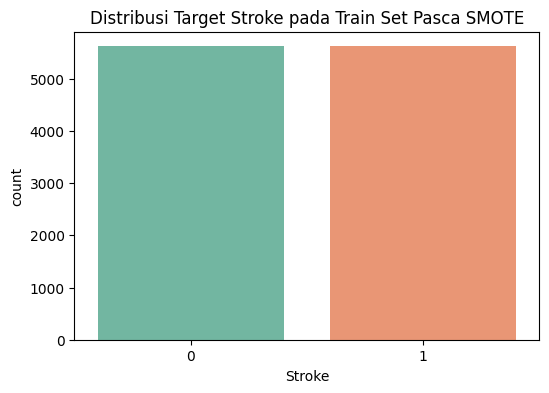

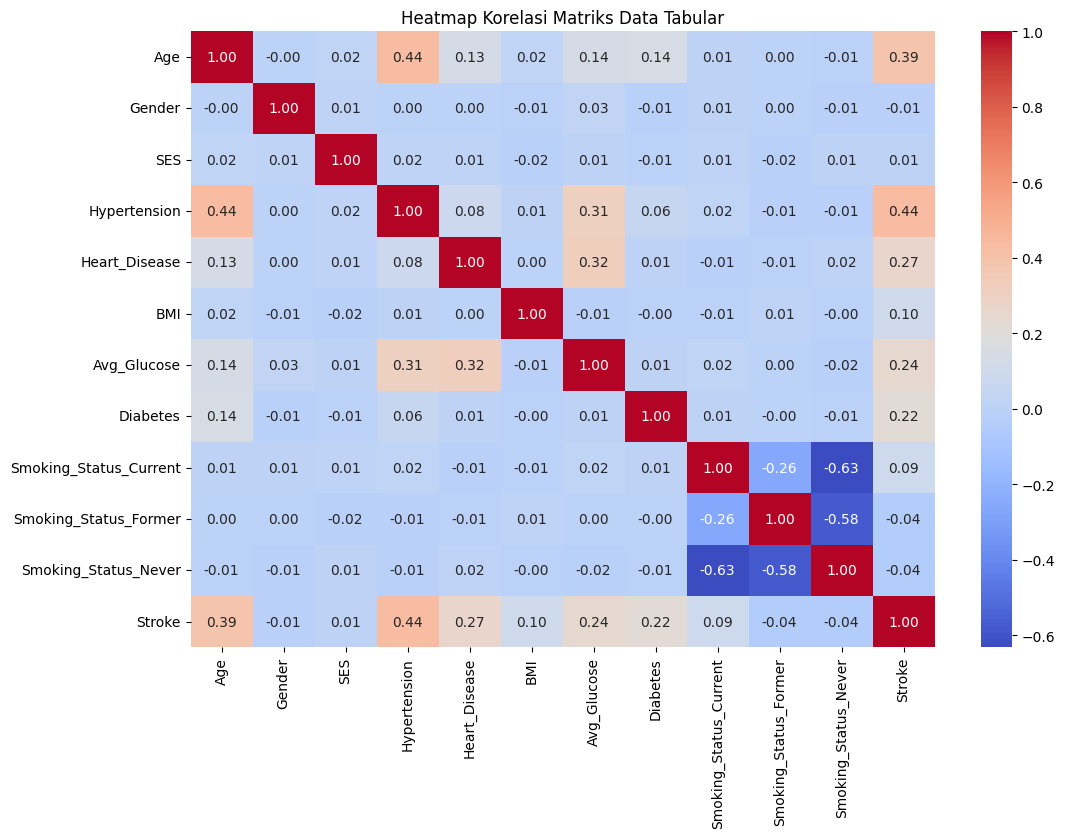

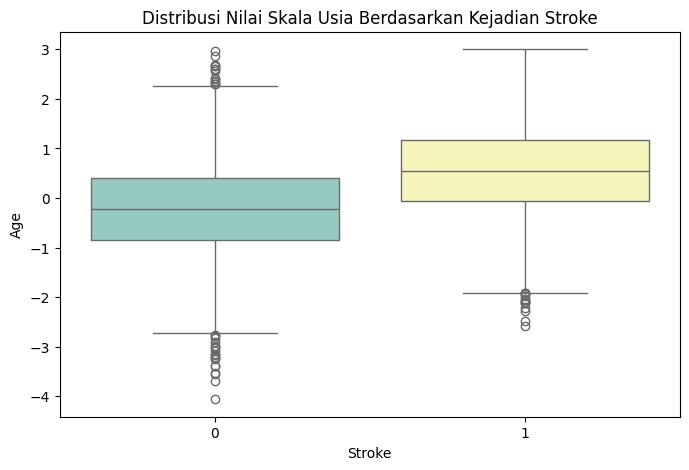


            EXPLANATORY ANALYSIS
1. Dataset awal terbukti mengalami ketidakseimbangan kelas (imbalance) yang signifikan, namun berhasil diseimbangkan pada subset pelatihan menggunakan metode SMOTE secara aman.
2. Berdasarkan matriks korelasi, variabel Usia (Age), Hipertensi (Hypertension), dan Penyakit Jantung (Heart_Disease) memiliki asosiasi positif tertinggi dengan risiko stroke.
3. Sebaran visual Boxplot menunjukkan pergeseran kuartil usia pasien stroke yang lebih tinggi, mengonfirmasi bahwa penuaan merupakan salah satu faktor risiko utama.
4. Nilai prapemrosesan parameter seperti pencarian median imputasi dan parameter rata-rata penskalaan StandardScaler dilakukan secara terpisah (Strict Splitting) untuk mengeliminasi celah Data Leakage.
5. Berkas akhir 'stroke_train_clean.csv' dan 'stroke_test_clean.csv' telah siap digunakan untuk melatih algoritma Machine Learning Classifier (seperti Logistic Regression, Random Forest, atau XGBoost).


 ANALISIS DATA STROKE SELESAI


In [2]:
# =========================================================
# 1. IMPORT LIBRARY
# =========================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# =========================================================
# 2. MENDEFINISIKAN PERTANYAAN BISNIS (Sesuai Urutan Alur)
# =========================================================
print("""
=================================================
             BUSINESS QUESTIONS
=================================================
1. Apakah dataset mengalami ketidakseimbangan kelas (imbalance) sebelum SMOTE?
2. Faktor klinis apa saja yang memengaruhi risiko kejadian stroke?
3. Apakah variabel usia, hipertensi, dan penyakit jantung memiliki korelasi kuat?
4. Bagaimana pengaruh distribusi BMI dan rata-rata kadar glukosa terhadap stroke?
5. Bagaimana memastikan penanganan imbalance (SMOTE) bebas dari Data Leakage?
""")

# =========================================================
# 3. GATHERING DATA
# =========================================================
df = pd.read_csv('/content/stroke_data.csv')
print("Dataset berhasil dimuat ke dalam DataFrame.")

# =========================================================
# 4. ASSESSING DATA
# =========================================================
print("\n========== INFORMASI STRUKTUR DATA (ASSESSING) ==========")
print(df.info())

print("\n========== IDENTIFIKASI MISSING VALUES ==========")
print(df.isnull().sum())

# =========================================================
# 5. CLEANING DATA , STRICT SPLITTING (ANTI-DATA LEAKAGE), DAN DATA DICTIONARY
# =========================================================
# Penanganan Missing Value Awal secara Manual
cols_to_check = ['BMI', 'Avg_Glucose']
for col in cols_to_check:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())
print("\n Imputasi missing value awal berhasil ditangani.")

# --- Mencegah Data Leakage (Kriteria Utama) ---
# Memisahkan Fitur dan Target
X = df.drop('Stroke', axis=1)
y = df['Stroke']

print("\n Distribusi Kelas Target Awal (Imbalance Check):")
print(y.value_counts())

# Melakukan Pemisahan Data Latih & Uji di AWAL sebelum Rekayasa Fitur/SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n Strict Data Splitting Selesai. Train shape: {X_train.shape} | Test shape: {X_test.shape}")

# =========================================================
# 6. FEATURE ENGINEERING / PREPROCESSING (Terisolasi per Subset)
# =========================================================
# Salin data untuk menghindari SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

# A. Label Encoding (Gender)
le = LabelEncoder()
X_train['Gender'] = le.fit_transform(X_train['Gender'])
X_test['Gender'] = le.transform(X_test['Gender']) # Menggunakan parameter fit dari Train Set

# B. Ordinal Encoding (SES)
ses_dict = {'Low': 0, 'Medium': 1, 'High': 2}
X_train['SES'] = X_train['SES'].map(ses_dict)
X_test['SES'] = X_test['SES'].map(ses_dict)

# C. One-Hot Encoding (Smoking_Status) - Diselaraskan kolomnya
X_train = pd.get_dummies(X_train, columns=['Smoking_Status'])
X_test = pd.get_dummies(X_test, columns=['Smoking_Status'])
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# D. Feature Scaling (Age, BMI, Avg_Glucose) secara Independen
scaler = StandardScaler()
num_features = ['Age', 'BMI', 'Avg_Glucose']
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features]) # Hanya transform pada Test Set!

print("Preprocessing & Feature Scaling terisolasi selesai.")

# E. Data Dictionary
data_dict_data = {
    'Nama Fitur': [
        'Gender', 'Age', 'Hypertension', 'Heart_Disease',
        'Smoking_Status', 'Residential_Type', 'SES',
        'Avg_Glucose_Level', 'BMI', 'Stroke'
    ],
    'Tipe Data': [
        'Kategorikal (Nominal)', 'Numerik (Diskrit)', 'Kategorikal (Biner)', 'Kategorikal (Biner)',
        'Kategorikal (Nominal)', 'Kategorikal (Biner)', 'Kategorikal (Ordinal)',
        'Numerik (Kontinu)', 'Numerik (Kontinu)', 'Kategorikal (Biner)'
    ],
    'Deskripsi': [
        'Jenis kelamin dari pasien pemeriksaan.',
        'Usia pasien dalam satuan tahun.',
        'Riwayat apakah pasien menderita tekanan darah tinggi.',
        'Riwayat apakah pasien memiliki penyakit jantung.',
        'Status atau kebiasaan merokok dari pasien.',
        'Jenis lingkungan tempat tinggal atau domisili pasien.',
        'Socioeconomic Status (Status Sosial Ekonomi) pasien.',
        'Rata-rata kadar glukosa/gula di dalam darah pasien (mg/dL).',
        'Body Mass Index (Indeks Massa Tubuh) pasien (kg/m²).',
        'Status kejadian stroke (Variabel Target).'
    ],
    'Nilai / Batasan': [
        '0: Female, 1: Male',
        'Angka riil bulat (18 - 90)',
        '0: Tidak Ada, 1: Memiliki Hipertensi',
        '0: Tidak Ada, 1: Memiliki Penyakit Jantung',
        '0: Never Smoked, 1: Formerly Smoked, 2: Smokes',
        '0: Rural (Desa), 1: Urban (Kota)',
        '0: Low, 1: Medium, 2: High',
        'Angka desimal positif',
        'Angka desimal positif / NaN (sebelum imputasi)',
        '0: Tidak Stroke, 1: Terkena Stroke'
    ]
}

data_dictionary = pd.DataFrame(data_dict_data)
print("=======================================================================")
print("                      DOCUMENTATION: DATA DICTIONARY                   ")
print("=======================================================================")
display(data_dictionary)
# =========================================================
# 7. HANDLING IMBALANCE VIA SMOTE (Hanya Pada Training Set)
# =========================================================
# SMOTE diaplikasikan HANYA pada X_train dan y_train agar tidak merusak keaslian data uji
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\n Penanganan Imbalance Selesai:")
print(f"Dimensi Target Train Sebelum SMOTE : \n{y_train.value_counts()}")
print(f"Dimensi Target Train Setelah SMOTE : \n{y_train_res.value_counts()}")

# Ekspor Dataset Akhir Siap Pakai (Format CSV Terstruktur)
train_final = X_train_res.copy()
train_final['Stroke'] = y_train_res
train_final.to_csv('stroke_train_clean.csv', index=False)

test_final = X_test.copy()
test_final['Stroke'] = y_test
test_final.to_csv('stroke_test_clean.csv', index=False)
print("\n Dataset akhir sukses disimpan ke format CSV terpisah (Siap Masuk Pemodelan ML!)")

# =========================================================
# 8. EXPLORATORY DATA ANALYSIS (EDA)
# =========================================================
print("\n========== DESKRIPSI DATA TRAINING MATANG (EDA) ==========")
print(train_final.describe())

# =========================================================
# 9. VISUALISASI DATA
# =========================================================
# Visualisasi 1: Distribusi Target Pasca SMOTE di Training Set
plt.figure(figsize=(6,4))
sns.countplot(x='Stroke', data=train_final, palette='Set2')
plt.title('Distribusi Target Stroke pada Train Set Pasca SMOTE')
plt.show()

# Visualisasi 2: Heatmap Korelasi Fitur Terhadap Target
plt.figure(figsize=(12,8))
sns.heatmap(train_final.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Matriks Data Tabular')
plt.show()

# Visualisasi 3: Distribusi Umur Standar Terhadap Kejadian Stroke
plt.figure(figsize=(8,5))
sns.boxplot(x='Stroke', y='Age', data=train_final, palette='Set3')
plt.title('Distribusi Nilai Skala Usia Berdasarkan Kejadian Stroke')
plt.show()

# =========================================================
# 10. EXPLANATORY ANALYSIS
# =========================================================
print("""
=================================================
            EXPLANATORY ANALYSIS
=================================================
1. Dataset awal terbukti mengalami ketidakseimbangan kelas (imbalance) yang signifikan, namun berhasil diseimbangkan pada subset pelatihan menggunakan metode SMOTE secara aman.
2. Berdasarkan matriks korelasi, variabel Usia (Age), Hipertensi (Hypertension), dan Penyakit Jantung (Heart_Disease) memiliki asosiasi positif tertinggi dengan risiko stroke.
3. Sebaran visual Boxplot menunjukkan pergeseran kuartil usia pasien stroke yang lebih tinggi, mengonfirmasi bahwa penuaan merupakan salah satu faktor risiko utama.
4. Nilai prapemrosesan parameter seperti pencarian median imputasi dan parameter rata-rata penskalaan StandardScaler dilakukan secara terpisah (Strict Splitting) untuk mengeliminasi celah Data Leakage.
5. Berkas akhir 'stroke_train_clean.csv' dan 'stroke_test_clean.csv' telah siap digunakan untuk melatih algoritma Machine Learning Classifier (seperti Logistic Regression, Random Forest, atau XGBoost).
""")

print("\n ANALISIS DATA STROKE SELESAI")